# Classificazione delle carte di Magic: The Gathering tramite Rarita'

## Obiettivo del Progetto
L'obiettivo del progetto è costruire modelli di classificazione in grado di predire la rarita' di una carta Magic partendo
dalle sue caratteristiche descrittive. La variabile target del nostro problema è "RARITY".
Il dataset utilizzato contiene informazioni sulle carte, come costo di mana, mana value, tipo di carta, testo, forza/costituzione, colori, legalita'
e altre proprieta'.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
import sys
sys.executable

In [ ]:
df = pd.read_csv('../dataset/mtg_cards_unique.csv')
df.head()

## 1.Lettura e comprensione del dataset

in questa sezione viene analizzata la struttura iniziale del dataset, verificando il numero di carte, gli attributi disponibili, i tipi di dato e la presenza di valori mancanti.

In [5]:
print(f"Numero di righe: {df.shape[0]}")
print(f"Numero di colonne: {df.shape[1]}")

Numero di righe: 30614
Numero di colonne: 12


In [6]:
df.columns.tolist()

['NAME',
 'MANA_COST',
 'CMC',
 'TYPE',
 'RARITY',
 'CARD_TEXT',
 'POWER_TOUGHNESS',
 'FIRST_EDITION',
 'NUMBER_OF_EDITIONS',
 'PRICES',
 'LEGALITIES',
 'COLOR_PIE']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30614 entries, 0 to 30613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NAME                30614 non-null  str    
 1   MANA_COST           28927 non-null  str    
 2   CMC                 30614 non-null  float64
 3   TYPE                30614 non-null  str    
 4   RARITY              30614 non-null  str    
 5   CARD_TEXT           29508 non-null  str    
 6   POWER_TOUGHNESS     16714 non-null  str    
 7   FIRST_EDITION       30614 non-null  str    
 8   NUMBER_OF_EDITIONS  30614 non-null  int64  
 9   PRICES              29800 non-null  str    
 10  LEGALITIES          29998 non-null  str    
 11  COLOR_PIE           30614 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 2.8 MB


il dataset contiene attributi numerici categorici. La variabile 'CMC è numerica, mentre la maggior parte delle altre colonne è rappresentata come testo. Alcuni attributi, come costo di mana, testo, Power/Toughness, prezzi e legalita', presentano valori mancanti. '

In [10]:
column_summary = pd.DataFrame({
    "Tipo": df.dtypes,
    "Valori mancanti": df.isnull().sum(),
    "Percentuale mancante": (df.isnull().sum() / len(df) * 100).round(2),
    "Valori unici": df.nunique()
})

column_summary.sort_values(
    by="Valori unici",
    ascending=False
)

,Tipo,Valori mancanti,Percentuale mancante,Valori unici
NAME,str,0,0.00,30614
CARD_TEXT,str,1106,3.61,27653
PRICES,str,814,2.66,27145
TYPE,str,0,0.00,3618
MANA_COST,str,1687,5.51,1033
LEGALITIES,str,616,2.01,295
FIRST_EDITION,str,0,0.00,256
POWER_TOUGHNESS,str,13900,45.40,160
COLOR_PIE,str,0,0.00,32
CMC,float64,0,0.00,19


## 2. Controllo delle carte duplicate e delle diverse edizioni di stampa

Una stessa carta di Magic: The Gathering puo' essere pubblicata in piu' espansioni. E' quindi necessario verificare che il dataset non contenga piu' righe riferite alla stessa carta.

Questo controllo è importante perchè versioni quasi identiche della stessa carta non devono comparire contemporaneamente nel training set e nel test set.

In [12]:
numero_righe = len(df)
numero_nomi_unici = df["NAME"].nunique()
numero_duplicati = df.duplicated(subset=["NAME"]).sum()

print(f"Numero totale di righe: {numero_righe}")
print(f"Numero di nomi unici: {numero_nomi_unici}")
print(f"Numero di duplicati sul nome: {numero_duplicati}")

Numero totale di righe: 30614
Numero di nomi unici: 30614
Numero di duplicati sul nome: 0


In [13]:
duplicated_cards = df[
    df.duplicated(subset=["NAME"], keep=False)
].sort_values("NAME")

duplicated_cards


,NAME,MANA_COST,CMC,TYPE,RARITY,CARD_TEXT,POWER_TOUGHNESS,FIRST_EDITION,NUMBER_OF_EDITIONS,PRICES,LEGALITIES,COLOR_PIE


Il controllo mostra che ogni valore della colonna `NAME` compare una sola volta. Il dataset sembra quindi essere gia' organizzato in modo da rappresentare ogni carta mediante un unico record, aggregando le informazioni relative alle diverse edizioni. 

la colonna `NAME` verra' comunque conservata come variabile di raggruppamento durante la suddivisione tra training e test set, ma non sara' utilizzata come feature predittiva.

## 3. Analisi della variabile target

La variabile target del problema è `RARITY`. Il progetto considera le quatteo rarita' principali:

- Common
- Uncommon
- Rare
- Mythic

Le classi speciali `Special` e `Bonus` vengono escluse perchè contengono un numero molto ridotto di esempi e non appartengono al sistema ordinario delle quattro rarita' principali.

In [14]:
df["RARITY"].value_counts()

RARITY
Common      10158
Uncommon     9274
Rare         9213
Mythic       1898
Special        62
Bonus           9
Name: count, dtype: int64

In [15]:
main_rarities = [
    "Common",
    "Uncommon",
    "Rare",
    "Mythic"
]

df_model = df[
    df["RARITY"].isin(main_rarities)
].copy()

print(f"Righe del dataset originale: {len(df)}")
print(f"Righe dopo la selezione delle quattro classi: {len(df_model)}")

Righe del dataset originale: 30614
Righe dopo la selezione delle quattro classi: 30543


In [16]:
class_counts = df_model["RARITY"].value_counts()
class_percentages = (
    df_model["RARITY"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_distribution = pd.DataFrame({
    "Numero di carte": class_counts,
    "Percentuale": class_percentages
})

class_distribution

,Numero di carte,Percentuale
RARITY,,
Common,10158,33.26
Uncommon,9274,30.36
Rare,9213,30.16
Mythic,1898,6.21


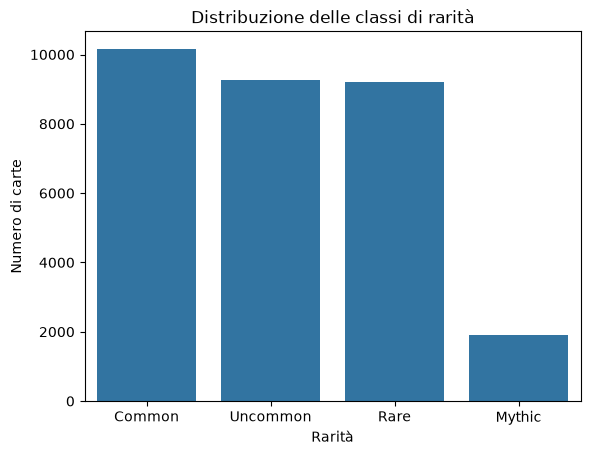

In [17]:
plt.Figure(figsize=(8, 5))

sns.countplot(
    data = df_model,
    x = "RARITY",
    order = main_rarities
)

plt.title("Distribuzione delle classi di rarità")
plt.xlabel("Rarità")
plt.ylabel("Numero di carte")
plt.show()

Le classi Common, Uncommon e rare hanno una numerosita' relativamente simile, mentre la classe Mythic è molto meno rappresentata.

Il dataset presenta un dislivello rilevabile sopratutto sulla classe delle Mythic. per questo motivo l'accuracy non sarà sufficiente per valutare i modelli. Verranno utilizzati anche la macro-F1 e la matrice di confusione. 